# Эксперимент 2.6
Оптимизационная точность vs качество на тесте (`лаб2.pdf`, п. 2.6).


In [1]:
%load_ext autoreload
%autoreload 2


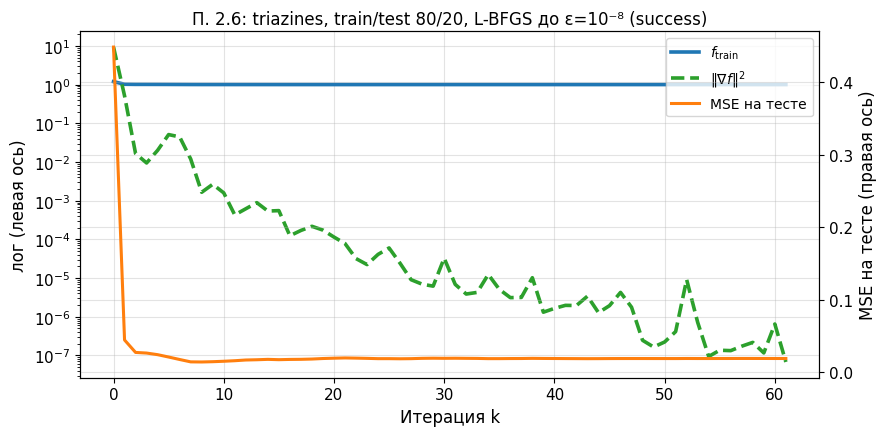

In [2]:
%matplotlib inline
import sys
import time
from pathlib import Path

_root = Path.cwd().resolve()
if _root.name == "notebooks":
    _root = _root.parent
_src = _root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import matplotlib.pyplot as plt
import numpy as np
from experiments_common import (
    TimedOracle,
    init_notebook,
    load_a1a,
    load_triazines,
    make_classification_oracle,
    make_regression_oracle,
    savefig_both,
    standard_regcoef,
    train_test_oracles_regression,
)
from ml_tools import sparse_oracle_ops
from optimization import (
    gradient_descent,
    hessian_free_newton,
    lbfgs,
    newton,
    newton_modified,
    nonlinear_conjugate_gradients,
    trust_region_steihaug_newton,
)
from oracles import NonConvexOracle, QuadraticOracle, beale_mesh_Z

init_notebook()

X, y = load_triazines()
otr, Xte, yte = train_test_oracles_regression(X, y, standard_regcoef(X.shape[0]))
mvAx_te, _, _ = sparse_oracle_ops(Xte)
x0 = np.zeros(X.shape[1])
line = {"method": "Wolfe", "alpha_0": 1.0}
_, msg, h = lbfgs(
    otr,
    x0,
    tolerance=1e-8,
    max_iter=5000,
    memory_size=20,
    line_search_options=line,
    trace=True,
    store_xk=True,
)
assert h and "xk" in h
mse_test = []
for xk in h["xk"]:
    pred = mvAx_te(xk)
    mse_test.append(float(np.mean((yte - pred) ** 2)))
fig, ax1 = plt.subplots(figsize=(9, 4.5))
it = np.arange(len(h["func"]))
ax1.semilogy(it, h["func"], color="C0", label=r"$f_{\mathrm{train}}$")
ax1.semilogy(it, np.array(h["grad_norm"]) ** 2, color="C2", linestyle="--", label=r"$\|\nabla f\|^2$")
ax1.set_xlabel("Итерация k")
ax1.set_ylabel("лог (левая ось)")
ax2 = ax1.twinx()
ax2.plot(it[: len(mse_test)], mse_test, color="C1", lw=2.2, label="MSE на тесте")
ax2.set_ylabel("MSE на тесте (правая ось)")
ax1.set_title("П. 2.6: triazines, train/test 80/20, L-BFGS до ε=10⁻⁸ ({})".format(msg))
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")
fig.tight_layout()
savefig_both(fig, "exp26_triazines_train_test")
plt.show()
